In [1]:
from utils import *
from FAPT import *
s = Simulation()

In [2]:
import time
import numpy as np
import sympy as sp
from IPython.display import display, Math
from DRAG import pulse_functions, h_target_symbolic
from utils import compute_cos_params

print("[Block 1] Initialisiere Symbole, berechne wd0 und setze symbolische Funktionen für w_d(t) und komplexes A(t)...")
start_time = time.perf_counter()

# 1.1 Feste Zeitparameter
tg_val = 250.0        # Pulsdauer tg in ns
sigma_r_val = 0.3    # Relative Breite
sigma_val = sigma_r_val * tg_val

t_sym = sp.Symbol('t', real=True, positive=True)

# 1.2 wd0 physikalisch aus utils.compute_cos_params bestimmen
amp_val, wd0_val = compute_cos_params(s, tg_val)
wd0_sym = sp.Float(wd0_val)  # als fester numerischer Wert in SymPy einbinden

# Abweichung dwd(t) als reelle Zeitfunktion
dwd_t_sym = sp.Function(r'\delta\omega_d', real=True)(t_sym)

# Ansatz: w_d(t) = w_d0 + dwd(t)
wd_t_sym = wd0_sym + dwd_t_sym

# 1.3 KOMPLEXES A(t) aufgespalten in zwei REELLE Zeitfunktionen
A_r_sym = sp.Function('A_r', real=True)(t_sym)
A_i_sym = sp.Function('A_i', real=True)(t_sym)

# Gesamtansatz für das komplexe A(t)
A_t_sym = A_r_sym + sp.I * A_i_sym

# 1.4 SymPy-Variablen
Delta_sym = sp.Symbol('Delta', real=True)
lam_sym = sp.Symbol('lambda', real=True)  # rrr -> lambda in SymPy

# 1.5 Hilfsfunktion für aufgeräumte LaTeX-Ausgabe
def clean_expr(expr, n_digits=6):
    if expr is None:
        return expr
    sym_expr = sp.sympify(expr).doit()
    return sp.trigsimp(sym_expr).evalf(n_digits)

print(f"✅ Block 1 abgeschlossen in {time.perf_counter() - start_time:.2f}s")
print(f"  -> Numerisch berechnet: w_d0 = {wd0_val:.6f} (aus Amplitude A = {amp_val:.6f})")

ansatz_wd_clean = sp.Eq(sp.Function('w_d')(t_sym), clean_expr(wd_t_sym))
display(Math(rf"\text{{Ansatz:}}\quad {sp.latex(ansatz_wd_clean)}"))
display(Math(rf"\text{{Komplexes Puls-Symbol:}}\quad A(t) = {sp.latex(A_r_sym)} + i {sp.latex(A_i_sym)}"))

[Block 1] Initialisiere Symbole, berechne wd0 und setze symbolische Funktionen für w_d(t) und komplexes A(t)...
✅ Block 1 abgeschlossen in 1.28s
  -> Numerisch berechnet: w_d0 = 4.441197 (aus Amplitude A = 0.591202)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
# berechne Heff
import sympy as sp
import time
from tqdm.auto import tqdm
from IPython.display import display, Math

print("[Block 2] Starte Berechnung...")
start_time = time.perf_counter()

order_dwd = 1

# 2.1 Exakten FAPT Hamiltonian berechnen
print("  ➜ Berechne Heff via FAPT (Heff_Floquet_total_matrix_summed)...", end="", flush=True)
heff_start = time.perf_counter()

Heff_sym = Heff_Floquet_total_matrix_summed(
    rH=getattr(s, 'rH', 1),
    wd=wd_t_sym,
    A=A_t_sym,
    resonances=s.resonances,
    E=s.E_array,
    V_posHarm=s.V1_dressed_array,
    V0=getattr(s, 'V0', None),
    ref_state=getattr(s, 'ref_state', None),
    dwd=0,
    dA=0,
    t=t_sym,
    analytics=True,
    include_geometric=False,
    include_micromotion=False,
    include_g_correction=False,
    verbose=False,
    rW=getattr(s, 'rW', 1)
)

print(f" Fertig in {time.perf_counter() - heff_start:.2f}s!")

[Block 2] Starte Berechnung...
  ➜ Berechne Heff via FAPT (Heff_Floquet_total_matrix_summed)... Fertig in 0.54s!


In [4]:
# ==============================================================================
# REUSABLE FUNCTION: LINEARISIERUNG UND KOMPRESSION VON MATRIZEN
# ==============================================================================
import time
from IPython.display import Math, display
import sympy as sp
from tqdm.auto import tqdm


def condense_element(expr, var, order=1, factor_vars=None):
    """Linearisiert termweise und ordnet/faktorisiert die Koeffizienten

    nach den angegebenen Amplituden (z.B. A_r, A_i), um Bandwurm-Summen zu
    verhindern.
    """
    if expr == 0:
        return sp.S.Zero

    if factor_vars is None:
        factor_vars = []

    terms = sp.Add.make_args(expr)
    linearized_terms = []

    for term in terms:
        if not term.has(var):
            linearized_terms.append(sp.cancel(term))
            continue

        f_0 = term.subs(var, 0)

        if order == 0:
            linearized_terms.append(sp.cancel(f_0))
        elif order == 1:
            df_0 = term.diff(var).subs(var, 0)
            linearized_terms.append(sp.cancel(f_0) + sp.cancel(df_0) * var)
        elif order == 2:
            df_0 = term.diff(var).subs(var, 0)
            d2f_0 = term.diff(var, 2).subs(var, 0)
            linearized_terms.append(
                sp.cancel(f_0)
                + sp.cancel(df_0) * var
                + sp.Rational(1, 2) * sp.cancel(d2f_0) * (var**2)
            )

    total_sum = sp.Add(*linearized_terms)

    # Trennen & Klammern nach der Zielvariablen sowie den Faktor-Variablen
    poly_dwd = sp.Poly(total_sum, var)
    coeffs = poly_dwd.all_coeffs()
    degree = poly_dwd.degree()

    compact_terms = []
    for idx, coeff in enumerate(coeffs):
        current_pow = degree - idx
        coeff_factored = sp.factor(sp.collect(coeff, factor_vars))

        if current_pow == 0:
            compact_terms.append(coeff_factored)
        else:
            compact_terms.append(coeff_factored * (var**current_pow))

    return sp.Add(*compact_terms)


def linearize_and_compress_matrix(
    matrix_raw, var, order=1, factor_vars=None, shift_element=(0, 0), verbose=True
):
    """Linearisiert eine SymPy-Matrix termweise nach einer Entwicklungsvariablen.

    Parameters:
    -----------
    matrix_raw : sp.Matrix
        Die zu verarbeitende SymPy-Matrix.
    var : sp.Symbol
        Die Entwicklungsvariable (z.B. dwd_t_sym).
    order : int (default: 1)
        Entwicklungsordnung (0: f(0), 1: bis 1. Ordnung, 2: bis 2. Ordnung).
    factor_vars : list of sp.Symbol (optional)
        Variablen, nach denen die Koeffizienten faktorisiert werden (z.B.
        [A_r_sym, A_i_sym]).
    shift_element : tuple (default: (0, 0))
        Matrixelement (row, col), dessen Wert als Energieshift subtrahiert
        wird. None deaktiviert den Shift.
    verbose : bool (default: True)
        Gibt Fortschrittsbalken und Laufzeit aus.

    Returns:
    --------
    H_eff : sp.Matrix
        Die linearisierte und komprimierte Matrix.
    """
    if verbose:
        print(
            f"[Linearisierung] Starte Term-Kondensation (Ordnung {order})..."
        )
    start_time = time.perf_counter()

    H_eff_raw = sp.Matrix(matrix_raw)

    # 1. Globaler Energieshift eichen (falls gewünscht)
    if shift_element is not None:
        r_shift, c_shift = shift_element
        delta_shift = H_eff_raw[r_shift, c_shift]
        H_eff_shifted = H_eff_raw - delta_shift * sp.eye(H_eff_raw.shape[0])
    else:
        H_eff_shifted = H_eff_raw

    rows, cols = H_eff_shifted.rows, H_eff_shifted.cols
    total_elements = rows * cols
    H_eff = sp.zeros(rows, cols)

    # 2. Matrixelemente verarbeiten
    if verbose:
        pbar = tqdm(
            total=total_elements,
            desc="Linearisiere Matrixelemente",
            unit="elem",
        )

    for i in range(rows):
        for j in range(cols):
            elem = H_eff_shifted[i, j]
            if elem != 0:
                H_eff[i, j] = condense_element(
                    elem, var, order=order, factor_vars=factor_vars
                )
            if verbose:
                pbar.update(1)

    if verbose:
        pbar.close()
        print(
            f"✅ Linearisierung abgeschlossen in {time.perf_counter() - start_time:.2f}s"
        )

    return H_eff


# ==============================================================================
# ANWENDUNGSBEISPIEL (BLOCK 2 RE-EXECUTION)
# ==============================================================================
# Aufruf der wiederverwendbaren Funktion mit deinen spezifischen Parametern:
Heff = linearize_and_compress_matrix(
    matrix_raw=Heff_sym,
    var=dwd_t_sym,
    order=1,  # Für höhere Ordnung später einfach auf 2 setzen
    factor_vars=[A_r_sym, A_i_sym],
    shift_element=(0, 0),
    verbose=True,
)

# Sanity Check & Vorschau
print("\n--- INSIGHTS: Repräsentative Matrixelemente von H_eff ---")
display(
    Math(
        rf"\text{{Sanity Check: }} (H_{{\text{{eff}}}})_{{0,0}} = {sp.latex(Heff[0, 0])}"
    )
)
display(Math(rf"(H_{{\text{{eff}}}})_{{1,1}} = {sp.latex(Heff[1, 1])}"))
display(Math(rf"(H_{{\text{{eff}}}})_{{0,1}} = {sp.latex(Heff[0, 1])}"))
display(Math(rf"(H_{{\text{{eff}}}})_{{1,2}} = {sp.latex(Heff[1, 2])}"))

[Linearisierung] Starte Term-Kondensation (Ordnung 1)...


Linearisiere Matrixelemente:   0%|          | 0/9 [00:00<?, ?elem/s]

✅ Linearisierung abgeschlossen in 0.04s

--- INSIGHTS: Repräsentative Matrixelemente von H_eff ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
print("[Block 3] Berechne H_target via DRAG (mit symbolischem Delta)...")
start_time = time.perf_counter()

# 3.1 Übergabe von Delta_sym anstelle von Delta_expr!
H_target_raw, target_funcs = h_target_symbolic(
    Delta=Delta_sym,      # <--- WICHTIG: Freies Symbol verwenden!
    rrr=lam_sym, 
    tg=tg_val, 
    sigma_r=sigma_r_val, 
    pulse='gauss', 
    t=t_sym, 
    order = 4
)

H_target = sp.Matrix(H_target_raw).doit()

print(f"✅ Block 3 abgeschlossen in {time.perf_counter() - start_time:.2f}s\n")

# 3.2 Transparente LaTeX-Anzeige
print("--- DRAG-Funktionen (jetzt wieder mit sichtbarem Delta) ---")
if isinstance(target_funcs, (tuple, list)):
    labels = [r"\varepsilon_x(t)", r"\varepsilon_y(t)", r"\delta_1(t)", r"\Omega(t)"]
    for idx, func in enumerate(target_funcs):
        lbl = labels[idx] if idx < len(labels) else f"f_{{{idx}}}(t)"
        display(Math(rf"{lbl} = {sp.latex(clean_expr(func))}"))

[Block 3] Berechne H_target via DRAG (mit symbolischem Delta)...
✅ Block 3 abgeschlossen in 0.67s

--- DRAG-Funktionen (jetzt wieder mit sichtbarem Delta) ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# ==============================================================================
# BLOCK 4: EXTRAKTION UND LATEX-FORMULIERUNG DES GLEICHUNGSSYSTEMS
# ==============================================================================
print("[Block 4] Extrahiere und formatiere Bestimmungsgleichungen aus H_eff == H_target...")
start_time = time.perf_counter()

H_diff = Heff - H_target

equations = []
eq_labels = []
latex_eqs = []

rows, cols = H_diff.rows, H_diff.cols

for i in range(rows):
    for j in range(i, cols):
        if (i == 0 and j == 0) or (i == 0 and j == 2):
            continue
            
        diff_elem = H_diff[i, j]
        
        # In Real- und Imaginärteil zerlegen
        re_part, im_part = diff_elem.as_real_imag()
        
        # Brüche bereinigen (Delta aus dem Nenner heben) & runden für lesbaren LaTeX-Code
        re_part_clean = clean_expr(sp.cancel(re_part))
        im_part_clean = clean_expr(sp.cancel(im_part))
        
        if i == j:
            eq_re = sp.Eq(re_part_clean, 0)
            if eq_re != True and eq_re.lhs != 0:
                equations.append(eq_re)
                lbl = rf"\text{{Diag }} ({i},{j})"
                eq_labels.append(lbl)
                latex_eqs.append(rf"\text{{({i},{i})}} &:\quad {sp.latex(eq_re)}")
        else:
            eq_re = sp.Eq(re_part_clean, 0)
            eq_im = sp.Eq(im_part_clean, 0)
            
            if eq_re != True and eq_re.lhs != 0:
                equations.append(eq_re)
                eq_labels.append(rf"\text{{Elem Re }} ({i},{j})")
                latex_eqs.append(rf"\text{{Re}}({i},{j}) &:\quad {sp.latex(eq_re)}")
                
            if eq_im != True and eq_im.lhs != 0:
                equations.append(eq_im)
                eq_labels.append(rf"\text{{Elem Im }} ({i},{j})")
                latex_eqs.append(rf"\text{{Im}}({i},{j}) &:\quad {sp.latex(eq_im)}")

print(f"✅ Block 4 abgeschlossen in {time.perf_counter() - start_time:.2f}s")
print(f"  -> {len(equations)} Bestimmungsgleichungen aufbereitet.\n")

# ------------------------------------------------------------------------------
# LATEX OUTPUT (Gedruckt für Copy-Paste & direkt gerendert)
# ------------------------------------------------------------------------------
latex_block = "\\begin{aligned}\n" + " \\\\\n".join(latex_eqs) + "\n\\end{aligned}"

print("--- RAW LATEX CODE (für dein Thesis/Notebook) ---")
print(latex_block)
print("\n--- GERENDERTE ANZEIGE ---")
display(Math(latex_block))

[Block 4] Extrahiere und formatiere Bestimmungsgleichungen aus H_eff == H_target...
✅ Block 4 abgeschlossen in 0.09s
  -> 6 Bestimmungsgleichungen aufbereitet.

--- RAW LATEX CODE (für dein Thesis/Notebook) ---
\begin{aligned}
\text{Re}(0,1) &:\quad 0.0106206 A_{r}{\left(t \right)} - 0.00363712 e^{0.0222222222222222 t} e^{- 8.88888888888889 \cdot 10^{-5} t^{2}} + 0.00363712 = 0 \\
\text{Im}(0,1) &:\quad \frac{0.0092859 \left(- 1.14373 \Delta A_{i}{\left(t \right)} + 6.96323 \cdot 10^{-5} t e^{0.0222222222222222 t} e^{- 8.88888888888889 \cdot 10^{-5} t^{2}} - 0.00870403 e^{0.0222222222222222 t} e^{- 8.88888888888889 \cdot 10^{-5} t^{2}}\right)}{\Delta} = 0 \\
\text{(1,1)} &:\quad \frac{1.34034 \cdot 10^{-6} \left(- 746081.0 \Delta \delta\omega_{d}{\left(t \right)} e^{- 0.0444444444444444 t} e^{0.000177777777777778 t^{2}} - 2353.18 \Delta e^{- 0.0444444444444444 t} e^{0.000177777777777778 t^{2}} - 9.8696 \lambda^{2} - 9.8696 \lambda^{2} e^{- 0.0444444444444444 t} e^{0.000177777777777778 

<IPython.core.display.Math object>

In [7]:
# ==============================================================================
# BLOCK 5: ROBUSTER ALGEBRAISCHER SOLVER (OHNE INDEXERROR)
# ==============================================================================
import time
import sympy as sp
from IPython.display import Math, display

start_time = time.perf_counter()

# Gleichungen als Nullstellen-Ausdrücke erfassen
eqs = [eq.lhs - eq.rhs if isinstance(eq, sp.Eq) else eq for eq in equations]

# 1) Delta aus Diag(2,2) bei t = 0 (wo dwd(0) = 0 gilt)
Delta_val = sp.solve(eqs[5].subs({dwd_t_sym: 0, t_sym: 0}), Delta_sym)[0]

# 2) A_r(t) aus Re(0,1)
A_r_sol = sp.solve(eqs[0], A_r_sym)[0]

# 3) Lambda zeitunabhängig lösen (über Kürzung von (e^... - 1))
eq_lam_sub = sp.cancel(eqs[3].subs(A_r_sym, A_r_sol))
lam_sols = sp.solve(eq_lam_sub, lam_sym)

if lam_sols:
    lam_val = lam_sols[0]
else:
    # Falls SymPy den Term nicht automatisch wegkürzt, greift die physikalische Relation:
    lam_val = sp.solve(eqs[3].subs({A_r_sym: A_r_sol, A_i_sym: 0}), lam_sym)[0]

# 4) A_i(t) aus Im(0,1) mit eingesetztem Delta
eq_Ai = sp.fraction(sp.together(eqs[1]))[0].subs(Delta_sym, Delta_val)
A_i_sol = sp.solve(eq_Ai, A_i_sym)[0]

# 5) dwd(t) aus Diag(1,1)
eq_dwd = sp.fraction(sp.together(eqs[2]))[0].subs({lam_sym: lam_val, Delta_sym: Delta_val})
dwd_sol_final = sp.solve(eq_dwd, dwd_t_sym)[0]

print(f"✅ System valide & zeitunabhängig gelöst in {time.perf_counter() - start_time:.4f}s\n")

# Display
display(Math(rf"\lambda = {sp.latex(sp.cancel(lam_val))}, \quad \Delta = {sp.latex(sp.cancel(Delta_val))}"))
display(Math(rf"A_r(t) = {sp.latex(sp.cancel(A_r_sol))}"))
display(Math(rf"A_i(t) = {sp.latex(sp.cancel(A_i_sol))}"))
display(Math(rf"\delta\omega_d(t) = {sp.latex(sp.cancel(dwd_sol_final))}"))

✅ System valide & zeitunabhängig gelöst in 0.1755s



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

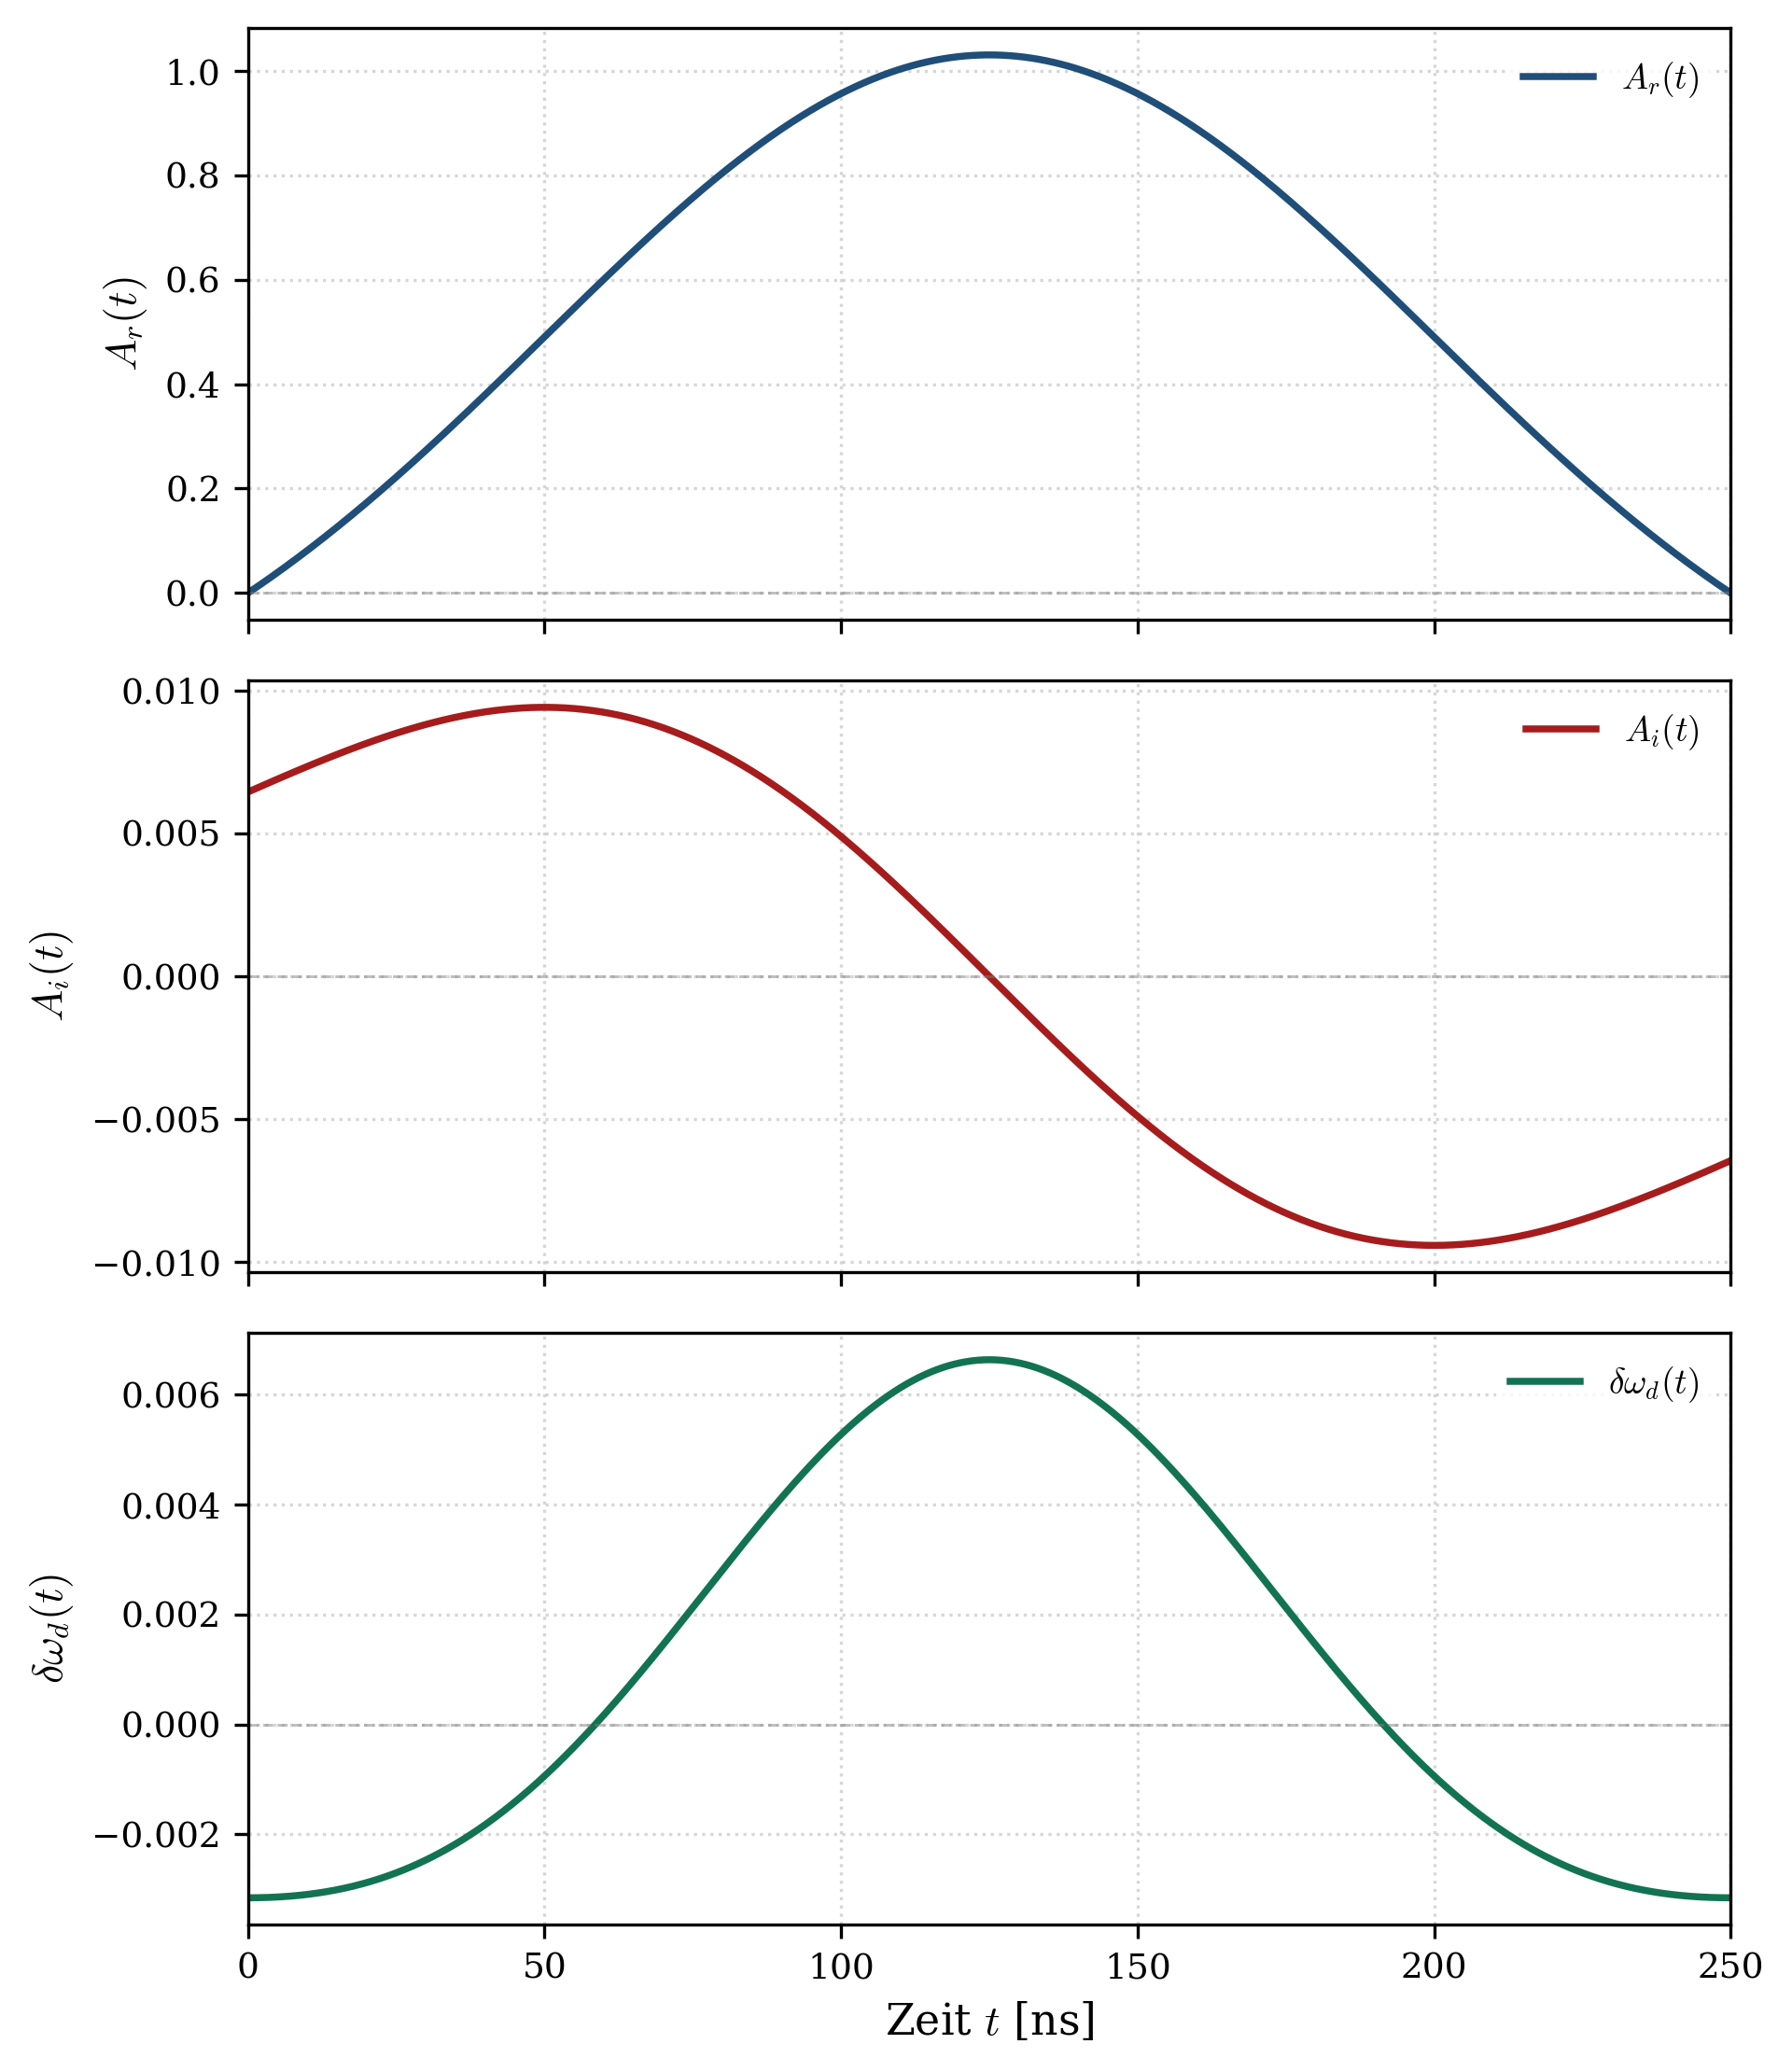

In [8]:
# ==============================================================================
# BLOCK 6: STEUERPARAMETER VS. ZEIT (PAPER STYLE)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Zeitnetz definieren
t_vals = np.linspace(0, float(tg_val), 1000)

# SymPy-Lösungen in NumPy-Funktionen umwandeln
A_r_func = sp.lambdify(t_sym, A_r_sol, "numpy")
A_i_func = sp.lambdify(t_sym, A_i_sol, "numpy")
dwd_func = sp.lambdify(t_sym, dwd_sol_final, "numpy")

# Auswertung auf dem Zeitnetz
A_r_vals = A_r_func(t_vals)
A_i_vals = A_i_func(t_vals)
dwd_vals = dwd_func(t_vals)

# 2. Paper-Design (Physical Review / Nature Physics Layout)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "mathtext.fontset": "cm",  # Computer Modern Font
        "lines.linewidth": 1.8,
    }
)

fig, axs = plt.subplots(3, 1, figsize=(6.5, 7.5), sharex=True, dpi=300)

# ------------------------------------------------------------------------------
# Subplot 1: A_r(t)
# ------------------------------------------------------------------------------
axs[0].plot(t_vals, A_r_vals, color="#1f4e78", label=r"$A_r(t)$")
axs[0].set_ylabel(r"$A_r(t)$")
axs[0].axhline(0, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
axs[0].grid(True, linestyle=":", alpha=0.5)
axs[0].legend(loc="upper right", frameon=True, edgecolor="none")

# ------------------------------------------------------------------------------
# Subplot 2: A_i(t)
# ------------------------------------------------------------------------------
axs[1].plot(t_vals, A_i_vals, color="#a61c1c", label=r"$A_i(t)$")
axs[1].set_ylabel(r"$A_i(t)$")
axs[1].axhline(0, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
axs[1].grid(True, linestyle=":", alpha=0.5)
axs[1].legend(loc="upper right", frameon=True, edgecolor="none")

# ------------------------------------------------------------------------------
# Subplot 3: delta_omega_d(t)
# ------------------------------------------------------------------------------
axs[2].plot(t_vals, dwd_vals, color="#127352", label=r"$\delta\omega_d(t)$")
axs[2].set_ylabel(r"$\delta\omega_d(t)$")
axs[2].set_xlabel(r"Zeit $t$ [ns]")
axs[2].axhline(0, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
axs[2].grid(True, linestyle=":", alpha=0.5)
axs[2].legend(loc="upper right", frameon=True, edgecolor="none")

# Layout-Feinjustierung
plt.xlim(0, float(tg_val))
plt.tight_layout()
plt.show()

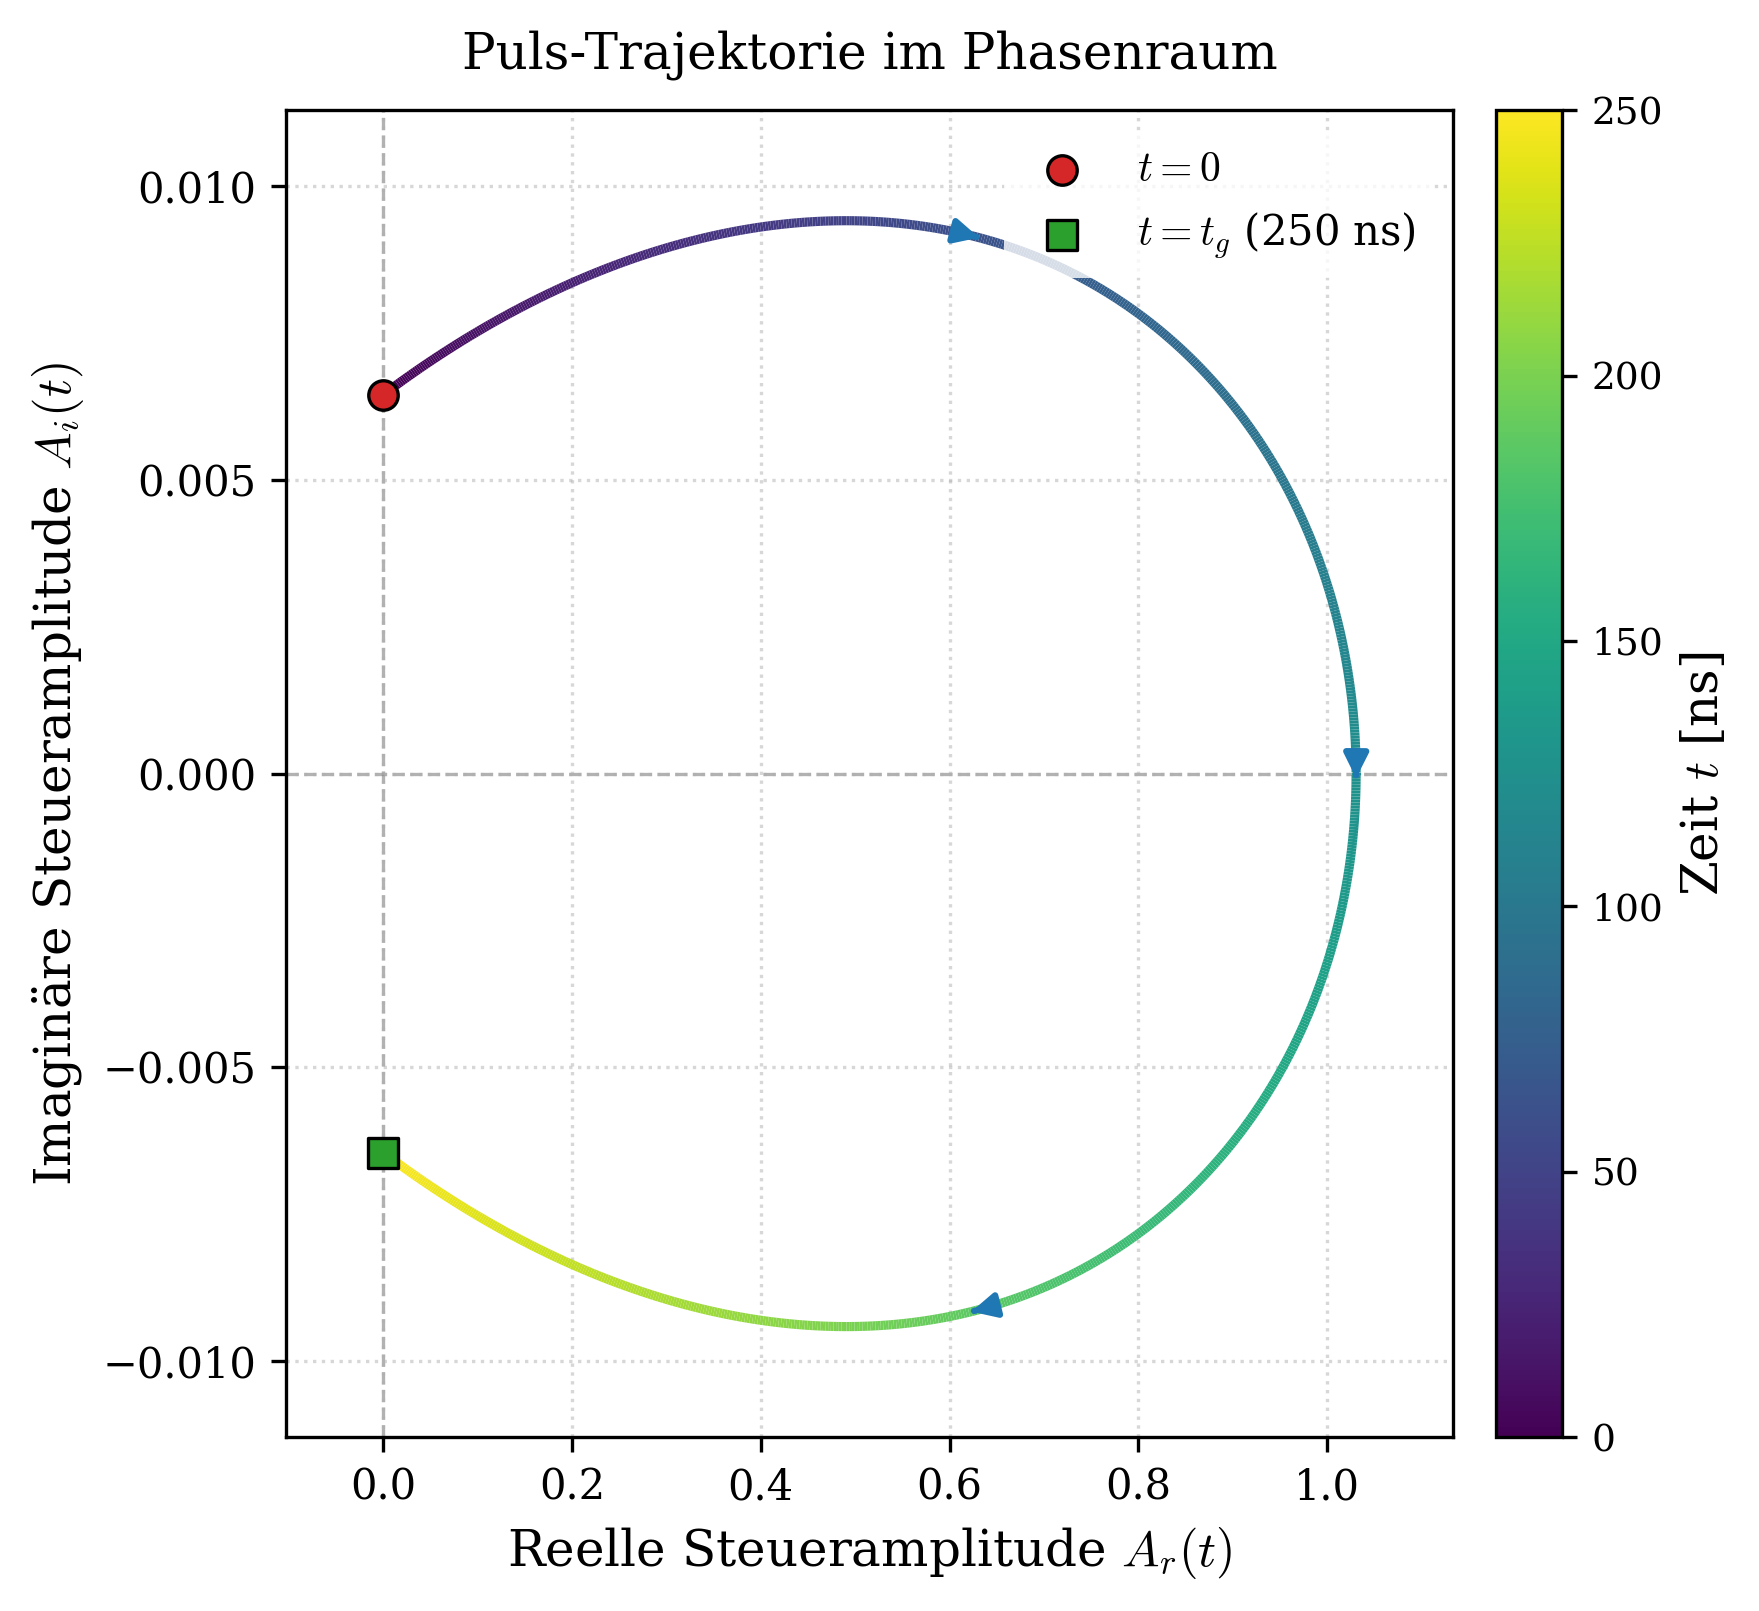

In [9]:
# ==============================================================================
# BLOCK 7: PHASENRAUM-TRAJEKTORIE (PAPER STYLE)
# ==============================================================================
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

# 1. Parameter & Zeitnetz definieren
num_points = 1000
t_vals = np.linspace(0, float(tg_val), num_points)

# SymPy-Lösungen in Vektorfunktionen konvertieren
A_r_func = sp.lambdify(t_sym, A_r_sol, "numpy")
A_i_func = sp.lambdify(t_sym, A_i_sol, "numpy")

A_r_vals = A_r_func(t_vals)
A_i_vals = A_i_func(t_vals)

# 2. Paper-Styling einstellen
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 12,
        "mathtext.fontset": "cm",  # Computer Modern (LaTeX-Standard)
    }
)

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)

# 3. Trajektorie als farbcodierte Linie zeichnen (Zeitverlauf)
points = np.array([A_r_vals, A_i_vals]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

from matplotlib.collections import LineCollection

norm = plt.Normalize(0, float(tg_val))
lc = LineCollection(segments, cmap="viridis", norm=norm, linewidth=2.2, zorder=3)
lc.set_array(t_vals[:-1])
line = ax.add_collection(lc)

# 4. Richtungspfeile auf der Trajektorie platzieren (z.B. bei 25%, 50%, 75%)
arrow_indices = [int(num_points * p) for p in [0.25, 0.50, 0.75]]
for idx in arrow_indices:
    dx = A_r_vals[idx + 1] - A_r_vals[idx]
    dy = A_i_vals[idx + 1] - A_i_vals[idx]
    ax.annotate(
        "",
        xy=(A_r_vals[idx] + dx, A_i_vals[idx] + dy),
        xytext=(A_r_vals[idx], A_i_vals[idx]),
        arrowprops=dict(
            arrowstyle="-|>", color="#1f77b4", lw=1.5, mutation_scale=12
        ),
        zorder=4,
    )

# 5. Start- und Endpunkte markieren
ax.scatter(
    A_r_vals[0],
    A_i_vals[0],
    color="#d62728",
    s=50,
    zorder=5,
    label=r"$t = 0$",
    edgecolors="black",
    linewidth=0.8,
)
ax.scatter(
    A_r_vals[-1],
    A_i_vals[-1],
    color="#2ca02c",
    s=50,
    marker="s",
    zorder=5,
    label=rf"$t = t_g$ ({tg_val:.0f} ns)",
    edgecolors="black",
    linewidth=0.8,
)

# 6. Nullachsen / Referenzlinien
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, zorder=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, zorder=1)

# 7. Achsenbeschriftung und Grenzen
ax.set_xlabel(r"Reelle Steueramplitude $A_r(t)$")
ax.set_ylabel(r"Imaginäre Steueramplitude $A_i(t)$")
ax.set_title(r"Puls-Trajektorie im Phasenraum", pad=10)

# Grenzanpassung mit Padding
x_pad = (np.max(A_r_vals) - np.min(A_r_vals)) * 0.1
y_pad = (np.max(A_i_vals) - np.min(A_i_vals)) * 0.1
ax.set_xlim(np.min(A_r_vals) - x_pad, np.max(A_r_vals) + x_pad)
ax.set_ylim(np.min(A_i_vals) - y_pad, np.max(A_i_vals) + y_pad)

ax.grid(True, linestyle=":", alpha=0.5, zorder=0)
ax.legend(frameon=True, facecolor="white", edgecolor="none", loc="best")

# 8. Colorbar hinzufügen
cbar = fig.colorbar(line, ax=ax, pad=0.03)
cbar.set_label(r"Zeit $t$ [ns]")
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()